<a href="https://colab.research.google.com/github/VielF/ColabProjects/blob/main/Pr%C3%A1tica_Filtragem_Espacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Universidade do Vale do Itajaí<br>
Escola Politécnica<br>
Processamento Digital de Sinais: Imagens

# Exercício Avalitivo de Filtragem Espacial

### Tutoriais da OpenCV

- https://docs.opencv.org/master/d9/df8/tutorial_root.html
- https://www.geeksforgeeks.org/opencv-python-tutorial/

## Conversão de imagem RGB em imagem Grayscale

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


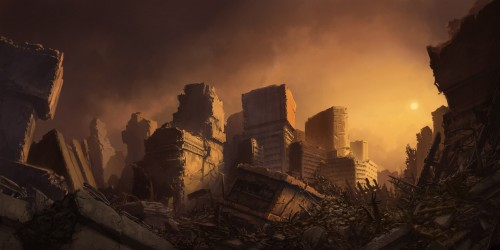

In [27]:
#abria a imagem
img = cv2.imread('/content/data/t1.jpg',1)
cv2_imshow(img)

In [5]:
#mostrando a imagem colorida
#cv2.imshow('in', img)
#cv2.waitKey(0)
#cv2.destroyAllWindows()

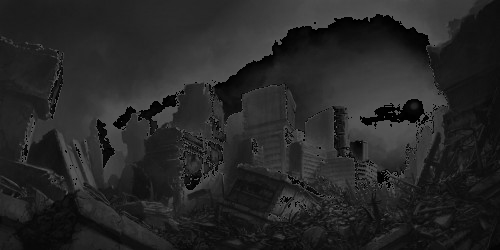

In [6]:
#aplicando conversão básica
#numpy
#img_grayscale_basic = (img[ : , : ,0]+img[ : , : ,1]+img[ : , : ,2])/3

#cv2
B, G, R = cv2.split(img)
img_grayscale_basic = (B+G+R)/3

img_grayscale_basic = np.array(img_grayscale_basic, dtype=np.uint8)

cv2_imshow(img_grayscale_basic)
##cv2.waitKey(0)
#cv2.destroyAllWindows()

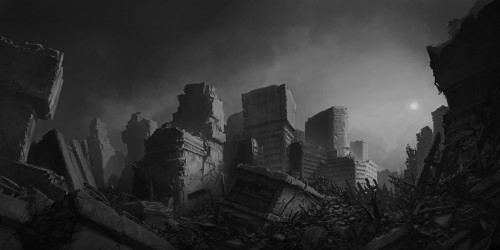

In [28]:
#aplicando conversão ponderada
#img_grayscale_basic = 0.299*img[ : , : ,0] + 0.587*img[ : , : ,1] + 0.114*img[ : , : ,2]

#cv2
B, G, R = cv2.split(img)
img_grayscale_pondered = 0.299*B+0.587*G+0.114*R

img_grayscale_pondered = np.array(img_grayscale_pondered, dtype=np.uint8)

cv2_imshow(img_grayscale_pondered)
#cv2.waitKey(0)
#cv2.destroyAllWindows()

## Filtro Espacial


In [29]:
def gauss_create(sigma=1, size_x=3, size_y=3):
    '''
    Create normal (gaussian) distribuiton
    '''
    x, y = np.meshgrid(np.linspace(-1,1,size_x), np.linspace(-1,1,size_y))
    calc = 1/((2*np.pi*(sigma**2)))
    exp = np.exp(-(((x**2) + (y**2))/(2*(sigma**2))))

    return exp*calc



In [36]:
print(gauss_create(sigma=0.5))
print(np.array(gauss_create(sigma=0.5)*255, dtype=np.uint8))

[[0.0116601  0.08615712 0.0116601 ]
 [0.08615712 0.63661977 0.08615712]
 [0.0116601  0.08615712 0.0116601 ]]
[[  2  21   2]
 [ 21 162  21]
 [  2  21   2]]


### Suavização

1. Implemente a sua própria convolução manualmente, em formato de função, utilizando os conceitos vistos em aula
2. Aplique a filtragem de suavização, com as máscaras 3x3, 5x5 e 7x7, com os filtros:
 - média
 - gaussino (escolha uma distribuição adequada, podendo utilizar a função acima ou recuperando a distribuição usada na OpenCV)
 - mediana
3. Relate as observações visíveis nas imagens de saída com os filtros usados, descrevendo o comportamento visual em relação as bordas, ruídos e esmaecimento da imagem com os diferentes kernels

#### Dicas
 - Você pode adicionar ruído nas imagens usando a função random_noise: `from skimage.util import random_noise`. Cuidado com o retorno da função, talvez seja necessário regularizar a mesma novamente para o intervalo de 0 à 255.

In [9]:
def add_padding(img, padding_height, padding_width):
    n, m = img.shape

    padded_img = np.zeros((n + padding_height * 2, m + padding_width * 2))
    padded_img[padding_height : n + padding_height, padding_width : m + padding_width] = img

    return padded_img

In [41]:
exemplo = np.ones((5,5))
print(exemplo)
print(add_padding(exemplo, (3//2), (3//2)))

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


In [18]:
from skimage.util import random_noise

In [10]:
def bubble_sort(arr):

    # Outer loop to iterate through the list n times
    for n in range(len(arr) - 1, 0, -1):

        # Inner loop to compare adjacent elements
        for i in range(n):
            if arr[i] > arr[i + 1]:

                # Swap elements if they are in the wrong order
                swapped = True
                arr[i], arr[i + 1] = arr[i + 1], arr[i]
    return arr


In [59]:
def conv2d(img, kernel, padding=True):
    # Get dimensions of the kernel
    k_height, k_width = kernel.shape  # Atribui valor à variável k_height, k_width

    # Get dimensions of the image
    img_height, img_width = img.shape  # Atribui valor à variável img_height, img_width

    # Calculate padding required
    pad_height = k_height // 2  # Atribui valor à variável pad_height
    pad_width = k_width // 2  # Atribui valor à variável pad_width

    # Create a padded version of the image to handle edges
    if padding == True:
        padded_img = add_padding(img, pad_height, pad_width)  # Atribui valor à variável padded_img

    #print(padded_img)

    # Initialize an output image with zeros
    output = np.zeros((img_height, img_width), dtype=float)  # Atribui valor à variável output

    # Perform convolution

    for i_img in range(img_height):  # Loop usando i
        for j_img in range(img_width):  # Loop usando j
            for i_kernel in range(k_height):
                for j_kernel in range(k_width):
                    output[i_img, j_img] = float(output[i_img, j_img]) + (float(padded_img[i_img+i_kernel, j_img+j_kernel]) * kernel[i_kernel, j_kernel])  # Atribui valor à variável output[i, j]
                    if(output[i_img, j_img] > 255): # operação de clip = np.clip()
                      output[i_img, j_img] = 255
                    elif (output[i_img, j_img] < 0):
                      output[i_img, j_img] = 0
            output[i_img, j_img] = int(output[i_img, j_img])

    return np.array(output, dtype=np.uint8)



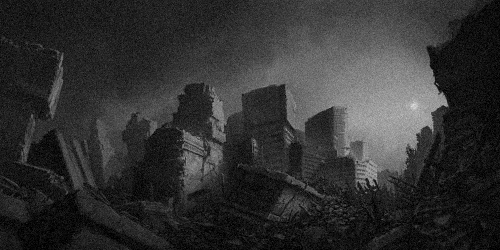

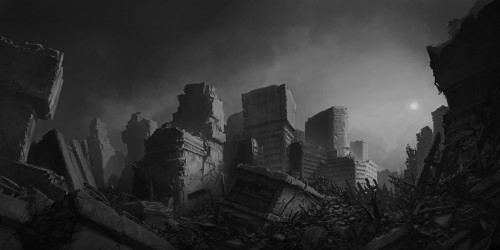

In [62]:
img_noise = random_noise(img_grayscale_pondered, mode='gaussian', var = 0.001)

img_noise = (img_noise * 255).astype(np.uint8)

cv2_imshow(img_noise)
cv2_imshow(img_grayscale_pondered)


[[ 7  9 11 ...  5  3  3]
 [ 9 12 14 ...  7  5  4]
 [11 14 17 ...  8  6  5]
 ...
 [11 14 17 ...  5  4  3]
 [ 9 12 14 ...  3  3  2]
 [ 7  9 11 ...  2  2  2]]
[[ 8 10 12 ...  5  4  3]
 [10 12 15 ...  7  6  5]
 [12 15 18 ...  9  6  5]
 ...
 [12 15 18 ...  5  4  4]
 [10 13 15 ...  4  3  3]
 [ 7  9 11 ...  3  2  2]]


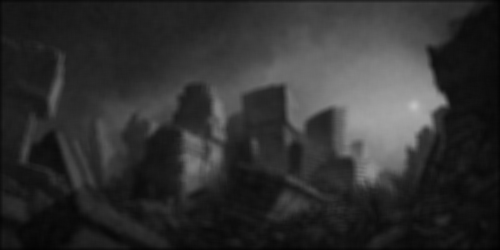

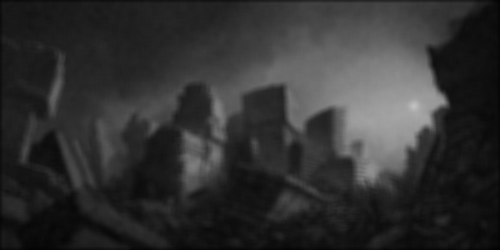

In [63]:
mean_3x3 = np.ones((3, 3))/9
mean_5x5 = np.ones((5, 5))/25
mean_7x7 = np.ones((7, 7))/49


img_mean = conv2d(img_noise, mean_7x7)
conv_opencv = cv2.filter2D(src=img_noise, ddepth=-1, kernel=mean_7x7, borderType=cv2.BORDER_CONSTANT)

print(img_mean)
print(conv_opencv)

cv2_imshow(img_mean)
cv2_imshow(conv_opencv)

[[21 28 33 ... 17 14 10]
 [32 42 48 ... 21 19 14]
 [39 51 59 ... 27 24 18]
 ...
 [34 48 59 ... 14 13 10]
 [27 38 47 ... 11 10  7]
 [19 27 34 ...  7  7  5]]
[[21 29 34 ... 17 15 11]
 [33 42 49 ... 22 20 15]
 [40 52 59 ... 27 25 19]
 ...
 [35 49 60 ... 15 14 10]
 [27 38 48 ... 12 11  8]
 [20 28 34 ...  8  7  5]]


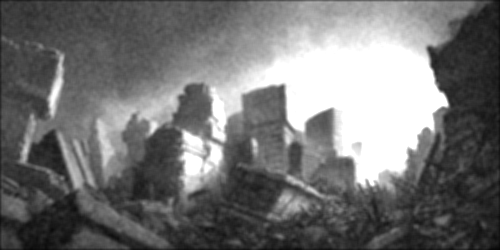

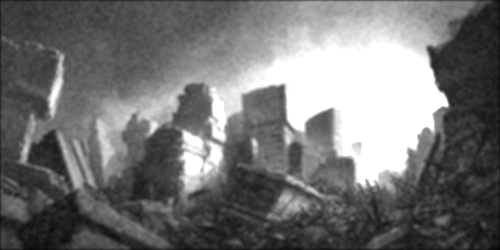

In [65]:
#gaussiano
gaus_3x3 = gauss_create(sigma=1, size_x=3, size_y=3)
gaus_5x5 = gauss_create(sigma=1, size_x=5, size_y=5)
gaus_7x7 = gauss_create(sigma=1, size_x=7, size_y=7)

img_mean = conv2d(img_noise, gaus_5x5)
conv_opencv = cv2.filter2D(src=img_noise, ddepth=-1, kernel=gaus_5x5, borderType=cv2.BORDER_CONSTANT)

print(img_mean)
print(conv_opencv)

cv2_imshow(img_mean)
cv2_imshow(conv_opencv)

In [14]:
def medianFilter(img, kernel, padding=True):
    # Get dimensions of the kernel
    k_height, k_width = kernel.shape  # Atribui valor à variável k_height, k_width

    # Get dimensions of the image
    img_height, img_width = img.shape  # Atribui valor à variável img_height, img_width

    # Calculate padding required
    pad_height = k_height // 2  # Atribui valor à variável pad_height
    pad_width = k_width // 2  # Atribui valor à variável pad_width

    # Create a padded version of the image to handle edges
    if padding == True:
        padded_img = add_padding(img, pad_height, pad_width)  # Atribui valor à variável padded_img
    else:
        padded_img = img
    #print(padded_img)

    # Initialize an output image with zeros
    output = np.zeros((img_height, img_width), dtype=float)  # Atribui valor à variável output
    kernel_vectorized = np.zeros(k_height*k_width)
    #print(kernel_vectorized)
    # Perform convolution
    for i_img in range(img_height):  # Loop usando i
        for j_img in range(img_width):  # Loop usando j
            i_vector = 0
            for i_kernel in range(k_height):
                for j_kernel in range(k_width):
                    kernel_vectorized[i_vector] = padded_img[i_img+i_kernel, j_img+j_kernel]  # Atribui valor à variável output[i, j]
                    i_vector+=1
            kernel_vectorized = bubble_sort(kernel_vectorized)
            median_index = int(((k_height*k_width)/2)+1)
            output[i_img, j_img] = int(kernel_vectorized[median_index])

    return np.array(output, dtype=np.uint8)

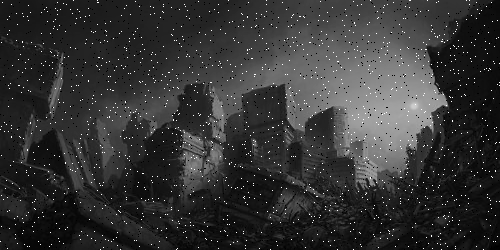

[[27 27 27 ... 13 13 12]
 [27 27 27 ... 13 13 13]
 [27 27 27 ... 13 13 13]
 ...
 [24 24 22 ...  3  4  2]
 [24 28 22 ...  4  4  4]
 [22 22 22 ...  4  4  0]]
[[27 27 27 ... 12 12 12]
 [27 27 27 ... 13 13 13]
 [27 27 27 ... 13 13 13]
 ...
 [24 24 22 ...  3  4  4]
 [24 22 22 ...  4  4  4]
 [28 22 22 ...  4  4  4]]


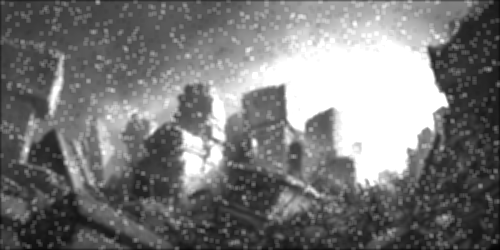

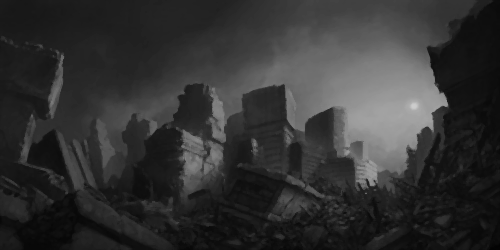

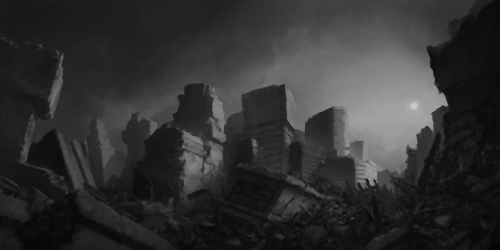

In [76]:
#gaussiano
img_noise = random_noise(img_grayscale_pondered, mode='s&p', amount = 0.025)

img_noise = (img_noise * 255).astype(np.uint8)

cv2_imshow(img_noise)

img_gaus = conv2d(img_noise, gaus_5x5)
img_meadian = medianFilter(img_noise, gaus_3x3, padding=True)
conv_opencv = cv2.medianBlur(img_noise, 3)
#print(img_noise)
print(img_mean)
print(conv_opencv)
cv2_imshow(img_gaus)
cv2_imshow(img_meadian)
cv2_imshow(conv_opencv)

### Sharpening

4. Implemente os filtros de sharpening, utilizando as diferentes mascarás apresentadas no livro de referência da disciplina:
 - Laplaciano (figura 3.37)
 - Sharpening implementado na figura 3.38
 - Unsharp Masking e Highboost Filtering
 - Implemente os detectores de borda Laplaciano, Roberts e Sobel
 - Utilize a função Canny da OpenCV na mesma imagem usando nos outros detectores

5. Relate as observações visíveis nas imagens de saída com os filtros usados, descrevendo o comportamento visual em relação as bordas, ruídos e esmaecimento da imagem com os diferentes kernels e para os diferentes algoritmos
6. Você observa uma discrepante melhoria na detecção de bordas pelo Canny em comparação aos outros 3 que justifique a complexidade adicional?
7. Aplique o filtro Sobel pós operação com um filtro de suavização (a sua escolha) e compare com a saída do Canny. Descreva suas observações técnicas sobre o comportamento.

In [81]:
def conv2d_sharpening(img, kernel, padding=True):
    # Get dimensions of the kernel
    k_height, k_width = kernel.shape  # Atribui valor à variável k_height, k_width

    # Get dimensions of the image
    img_height, img_width = img.shape  # Atribui valor à variável img_height, img_width

    # Calculate padding required
    pad_height = k_height // 2  # Atribui valor à variável pad_height
    pad_width = k_width // 2  # Atribui valor à variável pad_width

    # Create a padded version of the image to handle edges
    if padding == True:
        padded_img = add_padding(img, pad_height, pad_width)  # Atribui valor à variável padded_img

    #print(padded_img)

    # Initialize an output image with zeros
    output = np.zeros((img_height, img_width), dtype=float)  # Atribui valor à variável output

    # Perform convolution
    for i_img in range(img_height):  # Loop usando i
        for j_img in range(img_width):  # Loop usando j
            #calcula kernel
            for i_kernel in range(k_height):
                for j_kernel in range(k_width):
                    output[i_img, j_img] = float(output[i_img, j_img]) + (float(padded_img[i_img+i_kernel, j_img+j_kernel]) * float(kernel[i_kernel, j_kernel]))  # Atribui valor à variável output[i, j]
                    if(output[i_img, j_img] > 255): # operação de clip = np.clip()
                      output[i_img, j_img] = 255
                    #elif (output[i_img, j_img] < 0):
                    #  output[i_img, j_img] = 0
            output[i_img, j_img] = float(output[i_img, j_img])

    return np.array(output, dtype=np.float32)

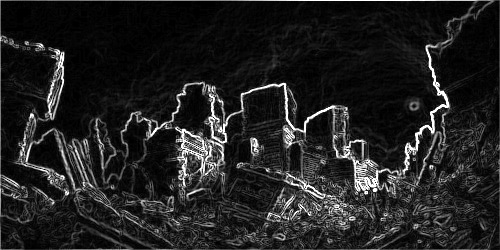

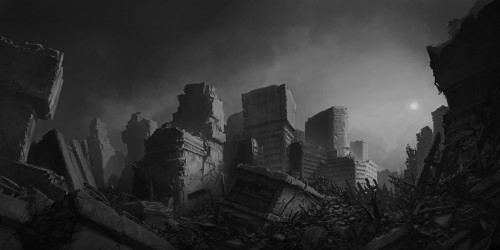

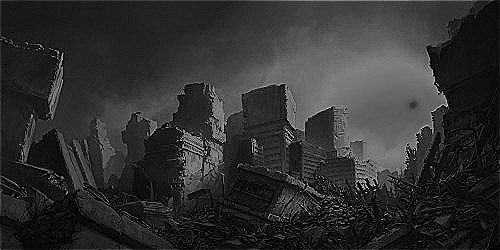

In [84]:
kernel_laplaciano = np.array(([0,-1,0],[-1,4,-1],[0,-1,0]))
kernel_roberts_1 = np.array(([-1,0],[0,1]))
kernel_roberts_2 = np.array(([0,-1],[1,0]))
kernel_sobel_1 = np.array(([-1,-2,-1],[0,0,0],[1,2,1]))
kernel_sobel_2 = np.array(([-1,0,1],[-2,0,2],[-1,0,1]))

img_sobel_1 = conv2d_sharpening(img_grayscale_pondered, kernel_sobel_1)
img_sobel_2 = conv2d_sharpening(img_grayscale_pondered, kernel_sobel_2)

img_sobel = np.abs(img_sobel_1)+np.abs(img_sobel_2)
cv2_imshow(img_sobel)

laplaciano = conv2d_sharpening(img_grayscale_pondered, kernel_laplaciano)

sharpened = np.zeros((img_grayscale_pondered.shape[0],img_grayscale_pondered.shape[1]))

for i in range(img_grayscale_pondered.shape[0]):
  for j in range(img_grayscale_pondered.shape[1]):
    sharpened[i,j] = float(img_grayscale_pondered[i,j]) + float(laplaciano[i,j])
    if sharpened[i,j] > 255:
      sharpened[i,j] = 255
    #sharpened[i,j] = np.array(sharpened[i,j], dtype=np.uint8)


cv2_imshow(img_grayscale_pondered)
cv2_imshow(sharpened)




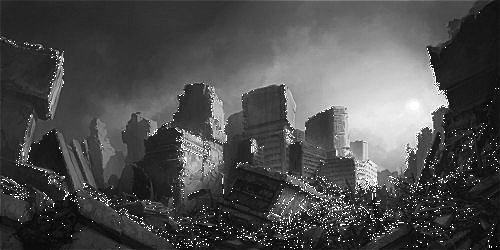

In [94]:
blur = conv2d(img_grayscale_pondered, gaus_3x3)

g = img_grayscale_pondered - blur

k=2

umhf = np.zeros((img_grayscale_pondered.shape[0],img_grayscale_pondered.shape[1]))

for i in range(img_grayscale_pondered.shape[0]):
  for j in range(img_grayscale_pondered.shape[1]):
    umhf[i,j] = float(img_grayscale_pondered[i,j]) + k*float(g[i,j])
    #if umhf[i,j] > 255:
    #  umhf[i,j] = 255
    #sharpened[i,j] = np.array(sharpened[i,j], dtype=np.uint8)

cv2_imshow(umhf)

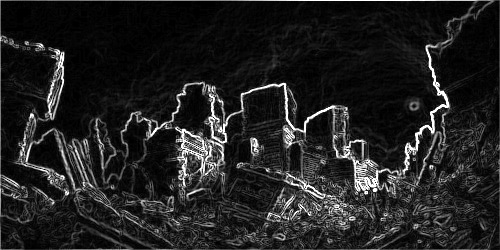

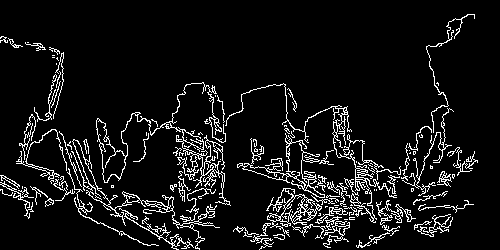

In [96]:
img_sobel_1 = conv2d_sharpening(img_grayscale_pondered, kernel_sobel_1)
img_sobel_2 = conv2d_sharpening(img_grayscale_pondered, kernel_sobel_2)

img_sobel = np.abs(img_sobel_1)+np.abs(img_sobel_2)
cv2_imshow(img_sobel)



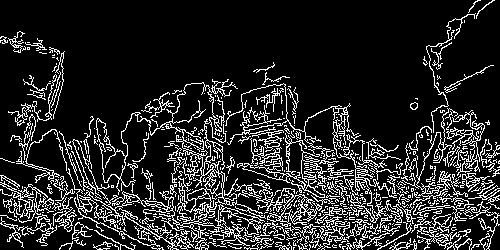

In [101]:
cv2_imshow(cv2.Canny(img_grayscale_pondered, 5 , 50))